
=== Hashed LinearSVR Model ===
MAE: 3.923695066854695
R^2: 0.42640758311592364
RMSE: 6.138122199184703
Saved plot to: /Users/davidfeng/Desktop/Edu/BU/4Se26S/CS506/finalProj/CS-506-final-project/diagram/model/LinearSVM(ActualvsPredicted).png


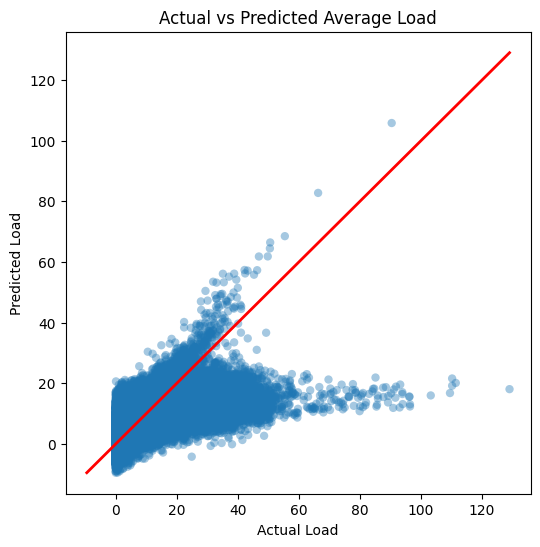

In [ ]:
# Imports
import sqlite3
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction import FeatureHasher
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVR
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    max_error,
    r2_score
)


# 1. Custom wrapper for FeatureHasher

class HashingEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, n_features=512):
        self.n_features = n_features
        self.hasher = FeatureHasher(n_features=n_features, input_type="dict")

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Convert categorical columns to list-of-dicts
        records = X.astype(str).to_dict(orient="records")
        return self.hasher.transform(records)


# 2. Load SQLite

PROJECT_ROOT = Path.cwd().parent.parent
DB_PATH = PROJECT_ROOT / "dataset" / "Ridership_v1.sqlite"

TABLE = "MBTA_Ridership"

conn = sqlite3.connect(DB_PATH)
query = """
SELECT
    season,
    route_name,
    stop_sequence,
    direction_id,
    day_type_name,
    time_period_name,
    stop_name,
    stop_id,
    average_ons,
    average_offs,
    average_load,
    num_trips,
    ons_all_trips
FROM MBTA_Ridership
WHERE average_load IS NOT NULL
"""
df = pd.read_sql_query(query, conn)
conn.close()


# 3. Clean data

categorical_cols = [
    "season",
    "route_name",
    "day_type_name",
    "time_period_name",
    "stop_name"
]

numeric_cols = [
    "stop_sequence",
    "direction_id",
    "stop_id",
    "average_ons",
    "average_offs",
    "num_trips",
    "ons_all_trips"
]

# Convert categorical → string
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

# Convert numeric → float
for col in numeric_cols + ["average_load"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()

X = df[categorical_cols + numeric_cols]
y = df["average_load"]


# 4. Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("hash", HashingEncoder(n_features=10000), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)


# 5. Model (FAST)

model = Pipeline([
    ("prep", preprocessor),
    ("svr", LinearSVR(C=1.0, max_iter=5000))
])


# 6. Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 7. Fit + evaluate

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
max_err = max_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)


print("\n=== Hashed LinearSVR Model ===")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"max_err: {max_err:.4f}")
print(f"R^2: {r2:.4f}")



# 8. Plot Actual vs Predicted

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4, edgecolor="none")
plt.xlabel("Actual Load")
plt.ylabel("Predicted Load")
plt.title("Actual vs Predicted Average Load")

# perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linewidth=2)


# 9. Save figure

save_dir = PROJECT_ROOT / "diagram" / "model"
save_dir.mkdir(parents=True, exist_ok=True)

file_path = save_dir / "LinearSVM(ActualvsPredicted).png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")

print("Saved plot to:", file_path)
